<a href="https://www.kaggle.com/code/sonawanelalitsunil/population-growth-analysis-ml-99-96?scriptVersionId=229918533" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/country-population-and-growth-rate-analysis/countries_population.csv


## Title : Population Growth Analysis

#### Description:
#### This analysis explores population trends, growth rates, and country-wise comparisons. It includes visualizations of population changes over time, top-growing nations, and predictive modeling using machine learning. 

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/country-population-and-growth-rate-analysis/countries_population.csv")

In [3]:
df.head()

,Country,ISO3,Year,Population,Population Growth,Growth Rate (%),Decade
0,Afghanistan,AFG,1960,8996973,NaN,NaN,1960s
1,Afghanistan,AFG,1961,9169410,172437.0,1.916611,1960s
2,Afghanistan,AFG,1962,9351441,182031.0,1.985199,1960s
3,Afghanistan,AFG,1963,9543205,191764.0,2.050636,1960s
4,Afghanistan,AFG,1964,9744781,201576.0,2.112246,1960s


In [4]:
df.tail()

,Country,ISO3,Year,Population,Population Growth,Growth Rate (%),Decade
15404,Zimbabwe,ZWE,2014,13586681,236325.0,1.770178,2010s
15405,Zimbabwe,ZWE,2015,13814629,227948.0,1.677731,2010s
15406,Zimbabwe,ZWE,2016,14030390,215761.0,1.561830,2010s
15407,Zimbabwe,ZWE,2017,14236745,206355.0,1.470772,2010s
15408,Zimbabwe,ZWE,2018,14439018,202273.0,1.420781,2010s


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15409 entries, 0 to 15408
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            15409 non-null  object 
 1   ISO3               15409 non-null  object 
 2   Year               15409 non-null  int64  
 3   Population         15409 non-null  int64  
 4   Population Growth  15146 non-null  float64
 5   Growth Rate (%)    15146 non-null  float64
 6   Decade             15409 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 842.8+ KB


In [6]:
df.describe()

,Year,Population,Population Growth,Growth Rate (%)
count,15409.000000,1.540900e+04,1.514600e+04,15146.000000
mean,1989.069764,2.081236e+08,3.297912e+06,1.813048
std,17.031017,6.868312e+08,1.067664e+07,1.632461
min,1960.000000,3.893000e+03,-6.740000e+06,-20.942049
25%,1974.000000,9.268410e+05,6.240500e+03,0.788829
50%,1989.000000,6.418773e+06,8.683650e+04,1.773408
75%,2004.000000,4.244904e+07,6.088282e+05,2.660330
max,2018.000000,7.594270e+09,9.037486e+07,32.392335


In [7]:
df.isnull().sum()

Country                0
ISO3                   0
Year                   0
Population             0
Population Growth    263
Growth Rate (%)      263
Decade                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.columns

Index(['Country', 'ISO3', 'Year', 'Population', 'Population Growth',
       'Growth Rate (%)', 'Decade'],
      dtype='object')

In [10]:
df.shape

(15409, 7)

In [11]:
df.dtypes

Country               object
ISO3                  object
Year                   int64
Population             int64
Population Growth    float64
Growth Rate (%)      float64
Decade                object
dtype: object

## data visualizations

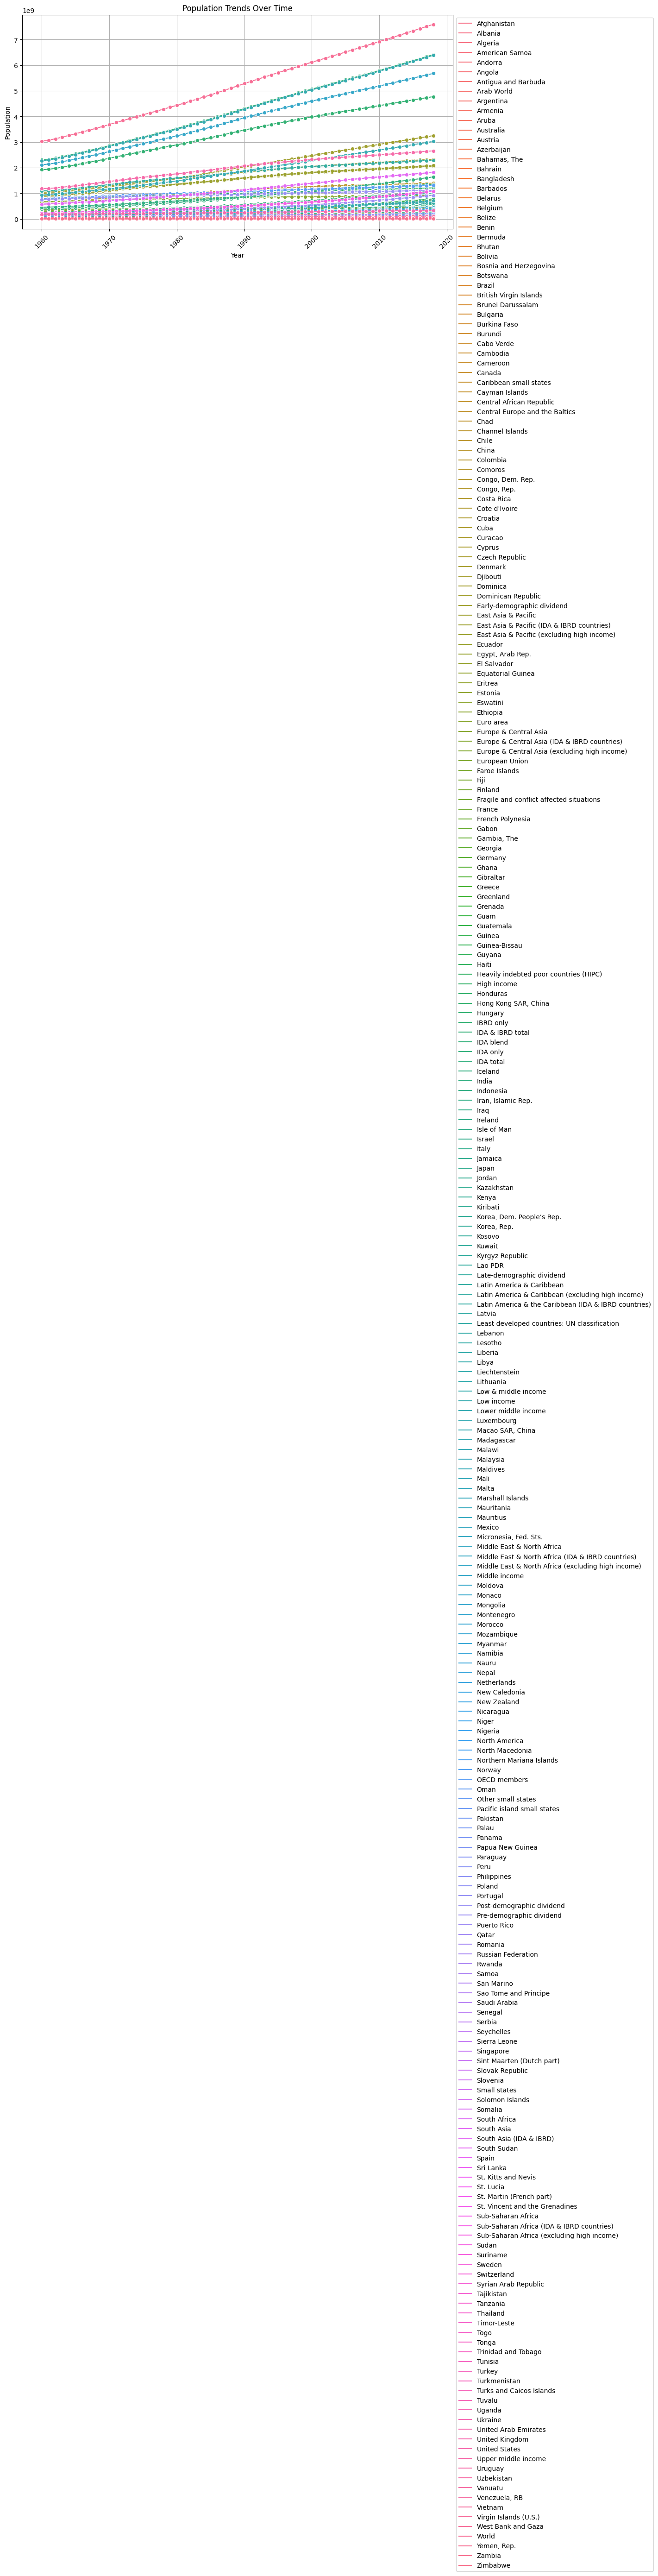

In [12]:
# Line chart for population trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Population', hue='Country', marker='o')
plt.title('Population Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

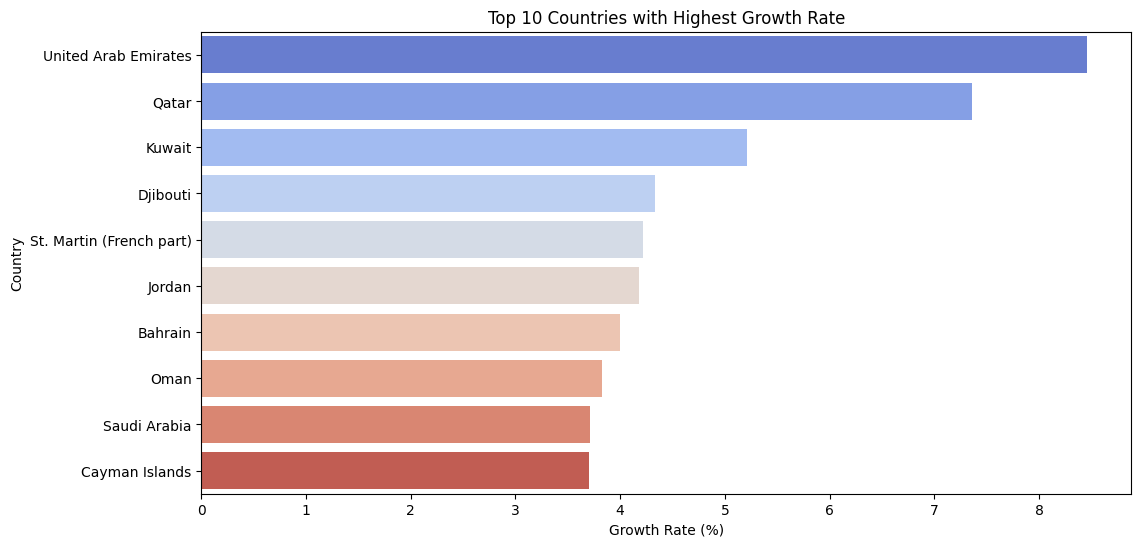

In [13]:
# Get top 10 countries by growth rate
top_growth = df.groupby('Country')['Growth Rate (%)'].mean().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_growth, x='Growth Rate (%)', y='Country', palette='coolwarm')
plt.title('Top 10 Countries with Highest Growth Rate')
plt.xlabel('Growth Rate (%)')
plt.ylabel('Country')
plt.show()


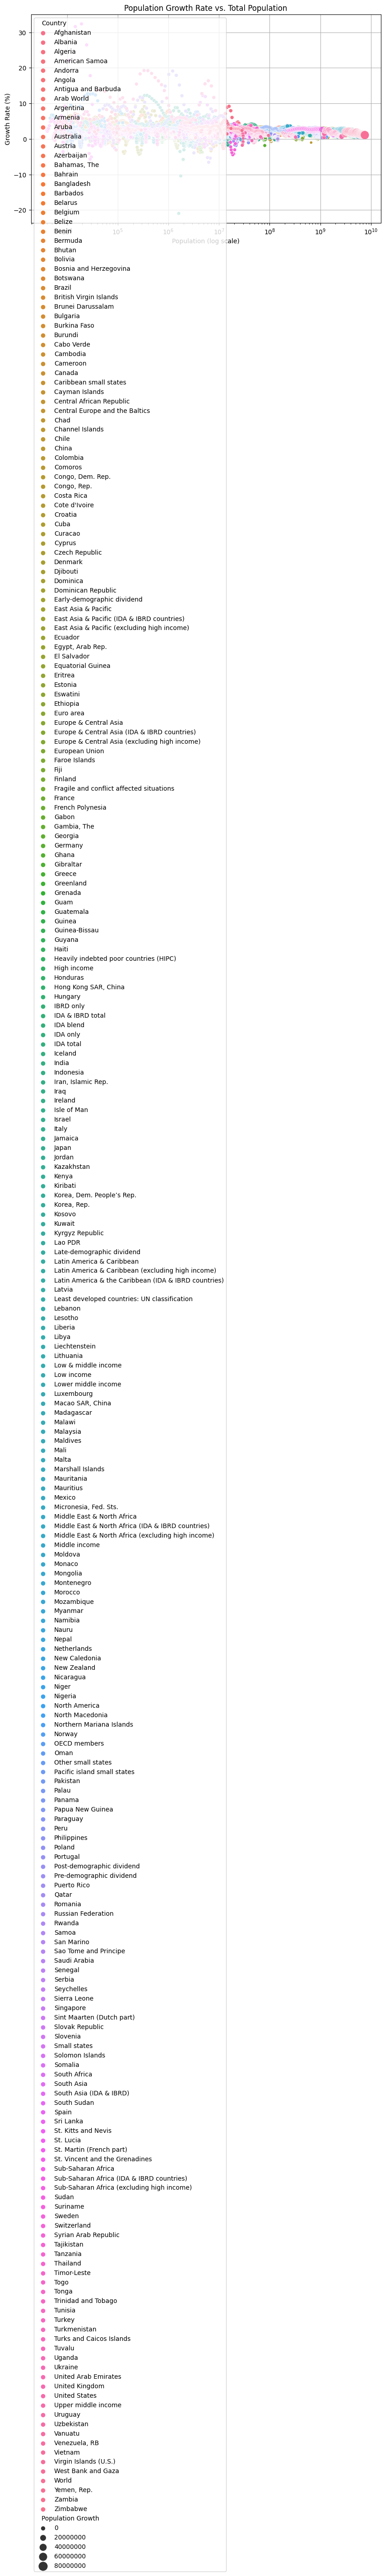

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Population', y='Growth Rate (%)', hue='Country', size='Population Growth', sizes=(20, 200))
plt.xscale('log')  # Log scale for better readability
plt.title('Population Growth Rate vs. Total Population')
plt.xlabel('Population (log scale)')
plt.ylabel('Growth Rate (%)')
plt.grid()
plt.show()

In [15]:
import plotly.express as px

# Aggregate by latest year
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

fig = px.choropleth(df_latest, 
                    locations="ISO3", 
                    color="Growth Rate (%)",
                    hover_name="Country",
                    color_continuous_scale="Blues",
                    title=f'Population Growth Rate by Country ({latest_year})')

fig.show()


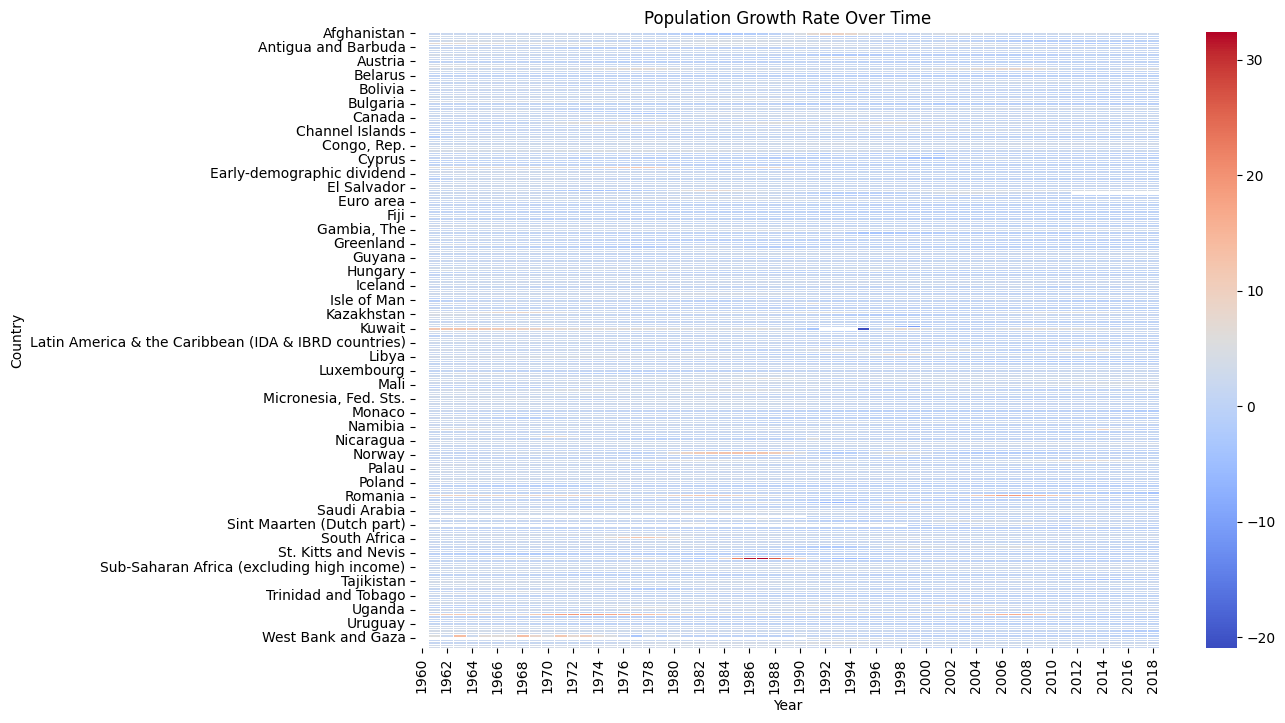

In [16]:
pivot_df = df.pivot(index='Country', columns='Year', values='Growth Rate (%)')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap='coolwarm', linewidths=0.5)
plt.title('Population Growth Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Country')
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [18]:
# Drop rows with missing values
df.dropna(inplace=True)

In [19]:
# Select features and target (Assume 'Growth Rate (%)' is the target)
X = df.drop(columns=['Growth Rate (%)', 'Country', 'ISO3'])  # Drop categorical columns except 'Decade'
y = df['Growth Rate (%)'] > 2  # Convert to binary classification (Above 2% Growth = 1, Otherwise = 0)

In [20]:
# Convert 'Decade' into numerical values using Label Encoding
le = LabelEncoder()
X['Decade'] = le.fit_transform(X['Decade'])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [23]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = acc

In [24]:
# Display accuracy results
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy (%)'])
print(results_df)

                    Model  Accuracy (%)
0     Logistic Regression     99.966997
1           Decision Tree     97.458746
2           Random Forest     97.788779
3       Gradient Boosting     95.049505
4  Support Vector Machine     56.930693
5                 XGBoost     98.283828


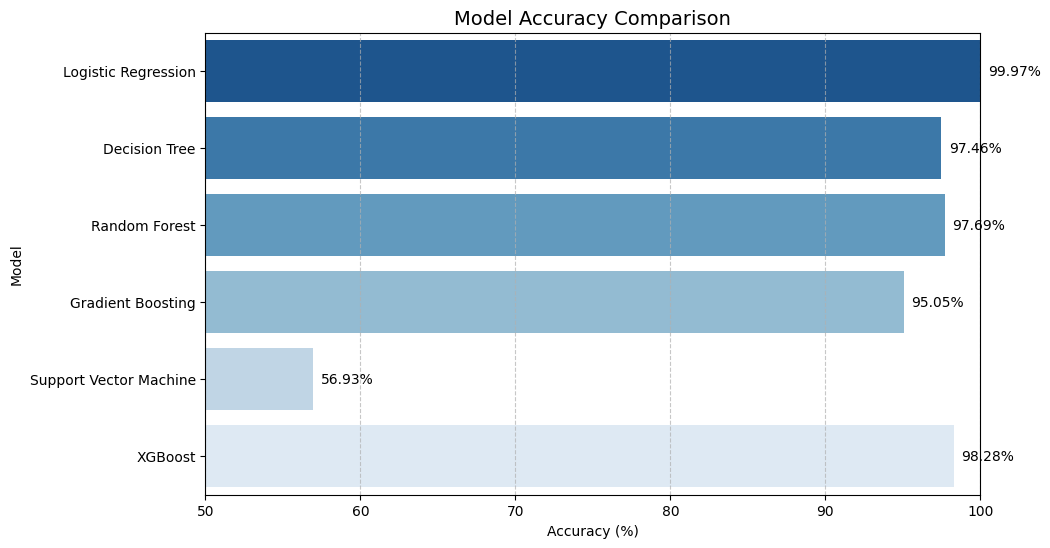

In [25]:
# Accuracy results in DataFrame format
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", 
              "Gradient Boosting", "Support Vector Machine", "XGBoost"],
    "Accuracy (%)": [99.97, 97.46, 97.69, 95.05, 56.93, 98.28]
})

# Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Accuracy (%)", y="Model", palette="Blues_r")

# Title and labels
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.xlim(50, 100)  # Adjust x-axis for better visibility
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Show values on bars
for index, value in enumerate(results_df["Accuracy (%)"]):
    plt.text(value + 0.5, index, f"{value:.2f}%", va="center")

plt.show()

## Thank you...pls upvote!!!